In [ ]:
# !pip install -r requirements.txt

In [2]:
import os
import numpy as np
import uuid
from sentence_transformers import SentenceTransformer
from chromadb import chromadb

/Users/kashish/Desktop/GenAI/LangChain/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Document Loading

In [ ]:
from langchain_community.document_loaders import TextLoader
text_doc = TextLoader(file_path="Sample/speech.txt")
text = text_doc.load()

In [ ]:
text[0].metadata

In [3]:
from langchain_community.document_loaders import PyMuPDFLoader
pdf_doc = PyMuPDFLoader(file_path="Sample/sample_file.pdf")

/var/folders/s5/ygdm_d1n1m37qg1c9ql_d12h0000gn/T/ipykernel_77797/2186427116.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


In [4]:
pdf = pdf_doc.load()

In [19]:
pdf

[Document(metadata={'producer': 'iTextSharp 4.1.1 (based on iText 2.1.1)', 'creator': '', 'creationdate': '2026-06-16T16:55:59+05:30', 'source': 'Sample/sample_file.pdf', 'file_path': 'Sample/sample_file.pdf', 'total_pages': 6, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-06-18T19:27:40+05:30', 'trapped': '', 'modDate': "D:20260618192740+05'30'", 'creationDate': "D:20260616165559+05'30'", 'page': 0}, page_content='FORM NO. 16\n[See rule 31(1)(a)]\nCertificate under Section 203 of the Income-tax Act, 1961 for tax deducted at source on salary paid to an employee under section 192 or pension/interest income\nof specified senior citizen under section 194P\nName and address of the Employer/Specified Bank\nMASTERS INDIA IT SOLUTIONS PRIVATE LIMITED\nS-201, CHETAN COMPLEX,\nSHRESTHA VIHAR, DELHI - 110092\nDelhi\n+(91)11-98712920\nTECCENTLAB@GMAIL.COM\nName and address of the Employee/Specified senior citizen\nSHUBHAM GOEL\nS/O UMESH GOEL, CHA

#### Text Splitting

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 20)

In [ ]:
text_split = splitter.split_documents(text)
text_split

In [6]:
pdf_split = splitter.split_documents(pdf)
pdf_split

[Document(metadata={'producer': 'iTextSharp 4.1.1 (based on iText 2.1.1)', 'creator': '', 'creationdate': '2026-06-16T16:55:59+05:30', 'source': 'Sample/sample_file.pdf', 'file_path': 'Sample/sample_file.pdf', 'total_pages': 6, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-06-18T19:27:40+05:30', 'trapped': '', 'modDate': "D:20260618192740+05'30'", 'creationDate': "D:20260616165559+05'30'", 'page': 0}, page_content='FORM NO. 16\n[See rule 31(1)(a)]\nCertificate under Section 203 of the Income-tax Act, 1961 for tax deducted at source on salary paid to an employee under section 192 or pension/interest income\nof specified senior citizen under section 194P\nName and address of the Employer/Specified Bank\nMASTERS INDIA IT SOLUTIONS PRIVATE LIMITED\nS-201, CHETAN COMPLEX,\nSHRESTHA VIHAR, DELHI - 110092\nDelhi\n+(91)11-98712920\nTECCENTLAB@GMAIL.COM\nName and address of the Employee/Specified senior citizen\nSHUBHAM GOEL'),
 Document(metadat

In [ ]:
with open("Sample/speech.txt", 'r') as f:
    speech_file = f.read()
text_doc = splitter.split_documents(splitter.create_documents([speech_file]))
text_doc

### Embeddings & Vectors

In [7]:
class EmbeddingModel:
    def __init__(self, model_name:str):
        self.model_name = model_name
        self.model = None
        self._load_model()
    
    def _load_model(self):
        self.model = SentenceTransformer(self.model_name)
        print(f"Model loaded with dimension {self.model.get_embedding_dimension()}")
    
    def get_encoded(self, text: str) -> np.ndarray:
        encoded_text = self.model.encode(text,show_progress_bar=True)
        return encoded_text


### VectorStore

In [8]:
class VectorDBStore:

    def __init__(self, collection_name: str, collection_path: str):
        self.collection_name = collection_name
        self.collection_path = collection_path
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):

        os.makedirs(self.collection_path, exist_ok=True)
        self.client = chromadb.PersistentClient(path=self.collection_path)
        self.collection = self.client.create_collection(name=self.collection_name,
                                                        metadata={"description": "PDF Document embeddings for RAG"},
                                                        get_or_create=True)
        print(f"Vector Store is initialized at {self.collection_path}")
    
    def _add_to_db(self, documents: list, embeddings: np.ndarray):
        if len(documents) != len(embeddings):
            raise ValueError("Length of Documents should match with length of embeddings")
        
        ids = []
        metadatas = []
        doc_texts = []
        doc_embeddings = []
        for each_doc, doc in enumerate(zip(documents, embeddings)):
            doc_id = f'doc_{uuid.uuid4().hex[:8]}_{each_doc}'
            ids.append(doc_id)
            doc_texts.append(doc[0].page_content)
            metadata = dict(doc[0].metadata)
            metadata.update({'doc_index': each_doc, 'content_length': len(doc[0].page_content)})
            metadatas.append(metadata)
            doc_embeddings.append(doc[1].tolist())
# can use add or upsert they both help in adding documents to the vector db just add(always fresh create), upsert(update if already there)
        self.collection.add(ids=ids,
                            embeddings=doc_embeddings,
                            metadatas=metadatas,
                            documents=doc_texts)
        print(f"Successfully added {len(documents)} documents to the DB")
        print(f"Total number of records in the collections are {self.collection.count()}")
        


In [9]:
emedding_model = EmbeddingModel('sentence-transformers/all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6137.60it/s]


Model loaded with dimension 384


In [ ]:
import shutil
import os
db_path = './data/pdf_vector'
if os.path.exists(db_path):
    shutil.rmtree(db_path)
    print(f"Removed {db_path}")
else:
    print("Database directory doesn't exist, will create fresh")

In [10]:
embeds_pdf = [emedding_model.get_encoded(doc.page_content) for doc in pdf_split]

Batches: 100%|██████████| 1/1 [00:00<00:00, 97.29it/s]


In [ ]:
for each, doc in enumerate(zip(pdf, embeds_pdf)):
    print(doc)
    break

In [11]:
vector_store = VectorDBStore('pdf_collection', './data/pdf_vector')

Vector Store is initialized at ./data/pdf_vector


In [12]:
vector_store._add_to_db(pdf_split, embeds_pdf)

Successfully added 31 documents to the DB
Total number of records in the collections are 62


In [ ]:
embeddings = emedding_model.get_encoded("The weather is too hot, in India!")
embeddings.shape

### Retriver Pipeline

In [46]:
class RetriverMaster:

    def __init__(self, vector_store: VectorDBStore, emedding_model: EmbeddingModel):
        self.vector_store = vector_store
        self.embedding_model = emedding_model
    
    def _query_embedding(self, user_query: str | None):
        if user_query:
            return self.embedding_model.get_encoded(user_query)
        print("Provide User Input!")
    
    def _similarity_search(self, user_embedding: np.ndarray):
        query_result = self.vector_store.collection.query(
            query_embeddings=user_embedding.tolist(),
            n_results=20 # n_results are number of results to be returned
        )
        ids = query_result['ids'][0]
        documents = query_result['documents'][0]
        distances = query_result['distances'][0]
        metadatas = query_result['metadatas'][0]
        result = []
        if query_result["documents"] and query_result["distances"]:
            for i,(doc_id, document, distance, metadata) in enumerate(zip(ids, documents, distances, metadatas)):
                similarity_score = 1 - distance
                if similarity_score > 0.0:
                    result.append({
                        "id": doc_id,
                        "document": document.format(),
                        "metadata": metadata,
                        "distance": distance,
                        "rank": i+1
                    })
        return result

In [47]:
retrive = RetriverMaster(vector_store=vector_store, emedding_model=emedding_model)

In [ ]:
user_embedding = retrive._query_embedding(user_query="What is the name of employee")
query_result = retrive._similarity_search(user_embedding=user_embedding)

In [ ]:
query_result

In [ ]:
for result in query_result:
    print(f"Rank: {result['rank']}")
    print(f"ID: {result['id']}")
    print(f"Document:\n{result['document']}")
    print(f"Distance: {result['distance']:.4f}")
    print(f"Similarity Score: {1 - result['distance']:.4f}")
    print("-" * 80)

### LLM integration

In [ ]:
# !pip install openai

In [15]:
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()

client = OpenAI(
    api_key=os.environ.get('GEMINI_KEY'),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

In [16]:
def rag_simple(retriver: RetriverMaster, query: str, client: OpenAI):
    results = retriver._similarity_search(retriver._query_embedding(query))
    context = "/n/n".join([content['document'] for content in results]) if results else ""
    if not context:
        return "No relevent information found for the asked query!"
    response = client.chat.completions.create(
        model="gemini-2.5-flash",
        messages=[
            {   "role": "system",
                "content": f"You are a helpful assistant. Make use of the {context} provided to answer the user query precisily."
            },
            {
                "role": "user",
                "content": query
            }
        ]
    )
    print(response.choices[0].message)

In [ ]:
user_query = "What is my final taxable income for this Financial Year"
rag_simple(retriver=retrive, query=user_query, client=client)

### LangGraph

In [29]:
from langgraph.graph import StateGraph, END
from typing import List, TypedDict

class AgentState(TypedDict):
    question: str
    need_retrieve: bool
    retriver: List
    result: str

In [24]:
def is_retriver(state: AgentState) -> AgentState:
    ques_keys = ['what', 'how', 'when', 'to be']
    if state.get('question'):
        req_que = state.get('question')
        if any(ques in req_que.lower() for ques in ques_keys):
            state['need_retrieve'] = True
        else:
            state['need_retrieve'] = False
    return state

In [25]:
def get_retriever(state: AgentState) -> AgentState:
    if state['need_retrieve']:
        state_retrive = retrive._similarity_search(retrive._query_embedding(state['question']))
        state['retriver'] = state_retrive
    return state

In [26]:
def get_llm_result(state: AgentState) -> AgentState:
    results = state["retriver"]
    context = "/n/n".join([content['document'] for content in results]) if results else ""
    if not context:
        system_prompt = "You are a helpful assistant. Answer the user query precisily."
    else:
        system_prompt = f"You are a helpful assistant. Make use of the {context} provided to answer the user query precisily."
    response = client.chat.completions.create(
        model="gemini-2.5-flash",
        messages=[
            {   "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": state['question']
            }
        ]
    )
    state["result"] = response.choices[0].message
    return state

In [38]:
def conditional_call(state:AgentState) -> str:
    if state['need_retrieve']:
        return "retriev"
    return "generate"

In [42]:
workflow = StateGraph(AgentState)

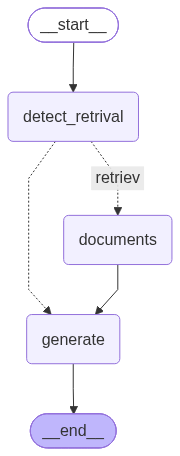

In [43]:
workflow.add_node('detect_retrival', is_retriver)
workflow.add_node('documents', get_retriever)
workflow.add_node('generate', get_llm_result)

workflow.set_entry_point('detect_retrival')

workflow.add_conditional_edges(
    'detect_retrival',conditional_call,{"retriev": 'documents', "generate": 'generate'}
)

workflow.add_edge("documents", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()
app

In [33]:
def ask_agent(question: str):

    agent_set = {
        "question": question,
        "need_retrieve": False,
        "retriver": [],
        "result": ""
    }

    return app.invoke(agent_set)

In [50]:
req_result = ask_agent("the taxable income?")
print(req_result["need_retrieve"])
req_result["result"].content

False


'To calculate or discuss "the taxable income," I need more information. Please specify:\n\n1.  **Whose taxable income** are you referring to (e.g., an individual, a specific type of business, a trust)?\n2.  **What is the gross income or revenue?**\n3.  **What are the applicable deductions, exemptions, and allowances?**\n4.  **What tax jurisdiction (country, state, etc.)** are you interested in, as tax laws vary significantly?\n\nGenerally, **taxable income** is the portion of an individual\'s or company\'s income that is subject to taxation, calculated by subtracting allowable deductions and exemptions from gross income.'